# Avance 3 — Equipo #48

![Tecnológico de Monterrey](https://i.imgur.com/tHk1B4P.png)

**Febrero 01, 2026**

| Nombre | Matrícula |
|--------|-----------|
| Jorge Daniel Amezola González | A01793759 |
| Diego Alejandro del Valle Pimentel | A01747310 |
| José Santiago Rueda Antonio | A01794118 |


---
## 1. Setup

In [1]:
1

1

In [2]:
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
from PIL import Image
from torchvision import transforms as T

import open_clip

plt.style.use('seaborn-v0_8-whitegrid')

# Dispositivo
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo: {device}")
if device == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"  VRAM: {vram_gb:.1f} GB")
else:
    print("  ADVERTENCIA: Sin GPU. El entrenamiento sera muy lento.")

Dispositivo: cuda
  GPU: NVIDIA GeForce RTX 4080 SUPER
  VRAM: 17.2 GB


In [3]:
DATA_DIR = Path("./train_data_v1")
METADATA_PATH = Path("../PASTIS-R/metadata.geojson")

# Cargar folds oficiales de PASTIS (evita fuga geografica)
with open(METADATA_PATH) as f:
    geojson = json.load(f)

patch_fold = {}
for feat in geojson["features"]:
    pid = int(feat["properties"]["ID_PATCH"])
    fold = int(feat["properties"]["Fold"])
    patch_fold[pid] = fold

# Solo patches que existen en train_data_v1
available_ids = sorted([
    int(p.stem) for p in DATA_DIR.glob("*.png")
    if (DATA_DIR / f"{p.stem}.txt").exists()
])

# Split: Folds 1-4 = train, Fold 5 = val
train_ids = [pid for pid in available_ids if patch_fold.get(pid, 0) in [1, 2, 3, 4]]
val_ids   = [pid for pid in available_ids if patch_fold.get(pid, 0) == 5]

print(f"Patches disponibles: {len(available_ids):,}")
print(f"Train (folds 1-4):   {len(train_ids):,}")
print(f"Val   (fold 5):      {len(val_ids):,}")

Patches disponibles: 2,433
Train (folds 1-4):   1,937
Val   (fold 5):      496


---
## 2. Dataset con augmentations

**Mejoras sobre v1:**

- **Augmentations de imagen para satelite:**
  - Rotacion aleatoria (0, 90, 180, 270 grados): las imagenes satelitales no tienen orientacion preferida
  - Flip horizontal/vertical: misma justificacion
  - Color jitter leve (brillo/contraste ±10%): simula variaciones atmosfericas sin destruir informacion espectral

- **Caption augmentation:**
  - 3 templates aleatorios por epoch para reducir overfitting al formato rigido
  - `"A satellite image containing: meadow, corn"`
  - `"satellite view of agricultural fields with meadow and corn"`
  - `"aerial crop image: meadow, corn"`

In [4]:
CAPTION_TEMPLATES = [
    "A satellite image containing: {crops}",
    "satellite view of agricultural fields with {crops_and}",
    "aerial crop image: {crops}",
]


def augment_caption(original_caption: str) -> str:
    """Genera una variacion aleatoria del caption original."""
    prefix = "A satellite image containing: "
    if original_caption.startswith(prefix):
        crop_str = original_caption[len(prefix):]
    else:
        crop_str = original_caption

    crops = [c.strip() for c in crop_str.split(",")]
    template = random.choice(CAPTION_TEMPLATES)

    if "{crops_and}" in template:
        if len(crops) > 1:
            crops_and = ", ".join(crops[:-1]) + " and " + crops[-1]
        else:
            crops_and = crops[0]
        return template.format(crops_and=crops_and)
    else:
        return template.format(crops=", ".join(crops))


# Demo
sample_caption = "A satellite image containing: meadow, corn, soft winter wheat"
print("Caption original:")
print(f"  {sample_caption}")
print("\nVariaciones:")
for _ in range(6):
    print(f"  {augment_caption(sample_caption)}")

Caption original:
  A satellite image containing: meadow, corn, soft winter wheat

Variaciones:
  A satellite image containing: meadow, corn, soft winter wheat
  A satellite image containing: meadow, corn, soft winter wheat
  satellite view of agricultural fields with meadow, corn and soft winter wheat
  satellite view of agricultural fields with meadow, corn and soft winter wheat
  A satellite image containing: meadow, corn, soft winter wheat
  satellite view of agricultural fields with meadow, corn and soft winter wheat


In [5]:
class SatelliteCLIPDatasetV2(Dataset):
    """Dataset mejorado con augmentations de imagen y texto para CLIP.

    Mejoras sobre v1:
    - satellite_augment: rotacion 90/180/270, flip H/V, color jitter
    - caption_augment: templates aleatorios para variedad textual
    """

    def __init__(self, data_dir, patch_ids, preprocess, tokenizer,
                 augment=False):
        self.data_dir = Path(data_dir)
        self.patch_ids = patch_ids
        self.preprocess = preprocess
        self.tokenizer = tokenizer
        self.augment = augment

        # Augmentations especificas para imagenes satelitales
        # Se aplican ANTES del preprocess de CLIP (que hace resize+normalize)
        self.satellite_augment = T.Compose([
            T.RandomChoice([
                T.Lambda(lambda x: x),                              # 0 grados
                T.Lambda(lambda x: x.rotate(90, expand=False)),     # 90 grados
                T.Lambda(lambda x: x.rotate(180, expand=False)),    # 180 grados
                T.Lambda(lambda x: x.rotate(270, expand=False)),    # 270 grados
            ]),
            T.RandomHorizontalFlip(p=0.5),
            T.RandomVerticalFlip(p=0.5),
            T.ColorJitter(
                brightness=0.1,   # ±10% brillo
                contrast=0.1,     # ±10% contraste
                saturation=0.05,  # ±5% saturacion (conservador para satelite)
                hue=0.0,          # NO tocar hue (cambiaria colores de cultivos)
            ),
        ])

        # Pre-cargar todos los captions en memoria (son ligeros)
        self.captions = {}
        for pid in patch_ids:
            txt_path = self.data_dir / f"{pid}.txt"
            self.captions[pid] = txt_path.read_text(encoding="utf-8").strip()

    def __len__(self):
        return len(self.patch_ids)

    def __getitem__(self, idx):
        pid = self.patch_ids[idx]

        # Imagen
        img = Image.open(self.data_dir / f"{pid}.png").convert("RGB")

        if self.augment:
            img = self.satellite_augment(img)

        img_tensor = self.preprocess(img)  # resize 224, normalize

        # Texto
        caption = self.captions[pid]
        if self.augment:
            caption = augment_caption(caption)

        text_tokens = self.tokenizer([caption])[0]  # (77,)

        return img_tensor, text_tokens


print("SatelliteCLIPDatasetV2 definido")

SatelliteCLIPDatasetV2 definido


---
## 3. Modelo CLIP — ViT-L/14

### **Upgrade de ViT-B/32 a ViT-L/14:**

#### Reconocimiento con CLIP y ViT-L/14
Se utiliza CLIP junto con ViT-L/14. El uso de zero-shot CLIP ayuda a determinar nueva información desconocida, o datos no estructurados, por el agente a base de lo que texto que se codifica junto con la imagen. Este _approach_ se considera útil para el problema debido a que se busca implementar el algoritmo de reconocimiento y narración de cultivos en nuevos tipos de cultivo. Adicionalmente se agrega el modelo ViT-L/14 debido a que este utiliza un Contrastive InfoNCE, el cual vence al previamente utilizado ViT-B/32.


| Aspecto | ViT-B/32 (v1) | ViT-L/14 (v2) |
|---------|---------------|---------------|
| Parametros | 151M | 428M (**2.8x**) |
| Patch size | 32x32 px | 14x14 px (**5.2x mas detalle**) |
| Embedding dim | 512 | 768 |
| Vision layers | 12 | 24 |
| VRAM (FP16, BS=128) | ~2.5 GB | ~6.5 GB |

Los patches 14x14 son criticos para imagenes satelitales: capturan parcelas
agricolas mas pequenas que los patches 32x32 del ViT-B ignoran.

Pre-entrenado en LAION-2B (`laion2b_s32b_b82k`): 32 billion samples vistos.

In [6]:
MODEL_NAME = "ViT-L-14"
PRETRAINED = "laion2b_s32b_b82k"

model, preprocess_train, preprocess_val = open_clip.create_model_and_transforms(
    MODEL_NAME, pretrained=PRETRAINED
)
tokenizer = open_clip.get_tokenizer(MODEL_NAME)

model = model.to(device)

# Contar parametros
total_params = sum(p.numel() for p in model.parameters())
visual_params = sum(p.numel() for n, p in model.named_parameters() if "visual" in n)
text_params = total_params - visual_params

print(f"Modelo: {MODEL_NAME} (pretrained: {PRETRAINED})")
print(f"Parametros totales:  {total_params:>12,}")
print(f"  Vision encoder:    {visual_params:>12,}")
print(f"  Text encoder:      {text_params:>12,}")
print(f"Tamano FP32:         {total_params * 4 / 1e9:.2f} GB")
print(f"Tamano FP16:         {total_params * 2 / 1e9:.2f} GB")

Modelo: ViT-L-14 (pretrained: laion2b_s32b_b82k)
Parametros totales:   427,616,513
  Vision encoder:     303,966,208
  Text encoder:       123,650,305
Tamano FP32:         1.71 GB
Tamano FP16:         0.86 GB


In [7]:
BATCH_SIZE = 128
GRAD_ACCUM_STEPS = 2   # batch efectivo = 128 * 2 = 256

train_ds = SatelliteCLIPDatasetV2(
    DATA_DIR, train_ids, preprocess_train, tokenizer, augment=True
)
val_ds = SatelliteCLIPDatasetV2(
    DATA_DIR, val_ids, preprocess_val, tokenizer, augment=False
)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=(device == "cuda"), drop_last=True,
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=(device == "cuda"),
)

# Verificar un batch
images, texts = next(iter(train_loader))
print(f"Batch de imagenes: {images.shape}")   # (128, 3, 224, 224)
print(f"Batch de tokens:   {texts.shape}")    # (128, 77)
print(f"Batches/epoca:     {len(train_loader)}")
print(f"Batch efectivo:    {BATCH_SIZE * GRAD_ACCUM_STEPS}")

Batch de imagenes: torch.Size([128, 3, 224, 224])
Batch de tokens:   torch.Size([128, 77])
Batches/epoca:     15
Batch efectivo:    256


---
## 4. Entrenamiento con mixed precision

**Hiperparametros v2:**

| Parametro | Valor | Justificacion |
|-----------|-------|---------------|
| **Optimizer** | AdamW | Estandar para fine-tuning de transformers |
| **LR** | 5e-6 | Mas conservador que v1 (1e-5) porque el modelo es 3x mas grande |
| **Weight decay** | 0.01 | Regularizacion L2 para prevenir overfitting |
| **Scheduler** | Cosine + warmup 2 epocas | Warmup mas largo para estabilizar modelo grande |
| **Batch efectivo** | 256 | 128 x 2 grad_accum — contrastive learning necesita muchos negativos |
| **Mixed precision** | FP16 autocast + GradScaler | 2x speedup, 50% menos VRAM |
| **Gradient clipping** | max_norm=1.0 | Estabilidad con mixed precision |
| **Early stopping** | patience=7 | Mas paciencia porque ViT-L converge mas lento |
| **Loss** | InfoNCE simetrica | Misma que v1 (estandar CLIP) |

In [8]:
N_EPOCHS = 30
LR = 5e-6
WEIGHT_DECAY = 0.01
PATIENCE = 7  # early stopping mas paciente para modelo grande

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Mixed precision scaler (solo para GPU)
use_amp = device == "cuda"
scaler = GradScaler("cuda", enabled=use_amp)

# Cosine annealing con warmup lineal de 2 epocas
warmup_steps = 2 * len(train_loader)  # 2 epocas de warmup
total_steps = N_EPOCHS * len(train_loader)


def lr_lambda(step):
    if step < warmup_steps:
        return step / warmup_steps  # warmup lineal
    progress = (step - warmup_steps) / max(total_steps - warmup_steps, 1)
    return 0.5 * (1 + np.cos(np.pi * progress))  # cosine decay


scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

print(f"Modelo:          {MODEL_NAME}")
print(f"LR:              {LR}")
print(f"Batch size:      {BATCH_SIZE} (x{GRAD_ACCUM_STEPS} accum = {BATCH_SIZE * GRAD_ACCUM_STEPS} efectivo)")
print(f"Epochs:          {N_EPOCHS}")
print(f"Steps/epoca:     {len(train_loader)}")
print(f"Total steps:     {total_steps}")
print(f"Warmup steps:    {warmup_steps} (2 epocas)")
print(f"Mixed precision: {use_amp}")
print(f"Early stopping:  patience={PATIENCE}")

Modelo:          ViT-L-14
LR:              5e-06
Batch size:      128 (x2 accum = 256 efectivo)
Epochs:          30
Steps/epoca:     15
Total steps:     450
Warmup steps:    30 (2 epocas)
Mixed precision: True
Early stopping:  patience=7


In [9]:
%%time
def clip_loss(model, images, texts):
    """Calcula la loss contrastiva simetrica (InfoNCE) de CLIP."""
    image_features = model.encode_image(images)
    text_features = model.encode_text(texts)

    # Normalizar a esfera unitaria
    image_features = F.normalize(image_features, dim=-1)
    text_features = F.normalize(text_features, dim=-1)

    # Similitud escalada
    logit_scale = model.logit_scale.exp()
    logits_per_image = logit_scale * image_features @ text_features.t()
    logits_per_text = logits_per_image.t()

    # Labels: cada imagen i debe matchear con texto i (diagonal)
    labels = torch.arange(len(images), device=images.device)

    # Loss simetrica
    loss_i2t = F.cross_entropy(logits_per_image, labels)
    loss_t2i = F.cross_entropy(logits_per_text, labels)
    loss = (loss_i2t + loss_t2i) / 2

    return loss



CPU times: user 2 μs, sys: 0 ns, total: 2 μs
Wall time: 4.29 μs


In [10]:
%%time
train_losses = []
val_losses = []
best_val_loss = float("inf")
patience_counter = 0

for epoch in range(N_EPOCHS):
    # --- Train ---
    model.train()
    epoch_loss = 0
    n_batches = 0
    optimizer.zero_grad()  # inicializar gradientes para accumulation

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{N_EPOCHS} [train]")
    for step, (images, texts) in enumerate(pbar):
        images = images.to(device)
        texts = texts.to(device)

        # Forward con mixed precision
        with autocast("cuda", enabled=use_amp):
            loss = clip_loss(model, images, texts)
            loss = loss / GRAD_ACCUM_STEPS  # normalizar para accumulation

        # Backward con scaler
        scaler.scale(loss).backward()

        # Actualizar pesos cada GRAD_ACCUM_STEPS
        if (step + 1) % GRAD_ACCUM_STEPS == 0 or (step + 1) == len(train_loader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            scheduler.step()

        epoch_loss += loss.item() * GRAD_ACCUM_STEPS  # des-normalizar
        n_batches += 1
        pbar.set_postfix(
            loss=f"{loss.item() * GRAD_ACCUM_STEPS:.4f}",
            lr=f"{scheduler.get_last_lr()[0]:.2e}",
        )

    avg_train_loss = epoch_loss / n_batches
    train_losses.append(avg_train_loss)

    # --- Validation ---
    model.eval()
    val_loss = 0
    val_batches = 0

    with torch.no_grad():
        for images, texts in val_loader:
            images = images.to(device)
            texts = texts.to(device)
            with autocast("cuda", enabled=use_amp):
                loss = clip_loss(model, images, texts)
            val_loss += loss.item()
            val_batches += 1

    avg_val_loss = val_loss / val_batches
    val_losses.append(avg_val_loss)

    # VRAM info
    vram_str = ""
    if device == "cuda":
        vram_used = torch.cuda.max_memory_allocated() / 1e9
        vram_str = f"  VRAM: {vram_used:.1f} GB"

    print(f"  Epoch {epoch+1}: train={avg_train_loss:.4f}  val={avg_val_loss:.4f}{vram_str}")

    # Early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "clip_pastis_v2_best.pt")
        print(f"  >>> Nuevo mejor modelo guardado (val_loss={best_val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"  Early stopping en epoca {epoch+1} (sin mejora en {PATIENCE} epocas)")
            break

print(f"\nMejor val_loss: {best_val_loss:.4f}")
print(f"Epocas completadas: {len(train_losses)}")

Epoch 1/30 [train]: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15/15 [35:12<00:00, 140.84s/it, loss=5.5005, lr=1.33e-06]


  Epoch 1: train=6.6547  val=5.1602  VRAM: 41.0 GB
  >>> Nuevo mejor modelo guardado (val_loss=5.1602)


Epoch 2/30 [train]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15/15 [22:02<00:00, 88.14s/it, loss=4.5318, lr=2.67e-06]


  Epoch 2: train=4.9612  val=4.7101  VRAM: 41.0 GB
  >>> Nuevo mejor modelo guardado (val_loss=4.7101)


Epoch 3/30 [train]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15/15 [20:33<00:00, 82.21s/it, loss=4.0604, lr=4.00e-06]


...

  Epoch 16: train=1.7659  val=4.1548  VRAM: 41.0 GB


Epoch 17/30 [train]: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15/15 [20:05<00:00, 80.39s/it, loss=1.6842, lr=4.25e-06]


  Epoch 17: train=1.6262  val=4.1965  VRAM: 41.0 GB


Epoch 18/30 [train]: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15/15 [20:06<00:00, 80.40s/it, loss=1.5775, lr=4.14e-06]


  Epoch 18: train=1.5156  val=4.2857  VRAM: 41.0 GB
  Early stopping en epoca 18 (sin mejora en 7 epocas)

Mejor val_loss: 3.8490
Epocas completadas: 18
CPU times: user 17h 49min 32s, sys: 9h 13min 1s, total: 27h 2min 34s
Wall time: 27h 2min 32s


In [ ]:
# ============================================================
# LOOP DE ENTRENAMIENTO
# ============================================================

train_losses = []
val_losses = []
best_val_loss = float("inf")
patience_counter = 0

for epoch in range(N_EPOCHS):
    # --- Train ---
    model.train()
    epoch_loss = 0
    n_batches = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{N_EPOCHS} [train]")
    for images, texts in pbar:
        images = images.to(device)
        texts = texts.to(device)

        loss = clip_loss(model, images, texts)

        optimizer.zero_grad()
        loss.backward()
        # Gradient clipping para estabilidad
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        epoch_loss += loss.item()
        n_batches += 1
        pbar.set_postfix(loss=f"{loss.item():.4f}", lr=f"{scheduler.get_last_lr()[0]:.2e}")

    avg_train_loss = epoch_loss / n_batches
    train_losses.append(avg_train_loss)

    # --- Validation ---
    model.eval()
    val_loss = 0
    val_batches = 0

    with torch.no_grad():
        for images, texts in val_loader:
            images = images.to(device)
            texts = texts.to(device)
            loss = clip_loss(model, images, texts)
            val_loss += loss.item()
            val_batches += 1

    avg_val_loss = val_loss / val_batches
    val_losses.append(avg_val_loss)

    print(f"  Epoch {epoch+1}: train_loss={avg_train_loss:.4f}  val_loss={avg_val_loss:.4f}")

    # Early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "clip_pastis_v1_best.pt")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"  Early stopping en epoca {epoch+1} (sin mejora en {PATIENCE} epocas)")
            break

print(f"\nMejor val_loss: {best_val_loss:.4f}")

---
## 5. Resultados

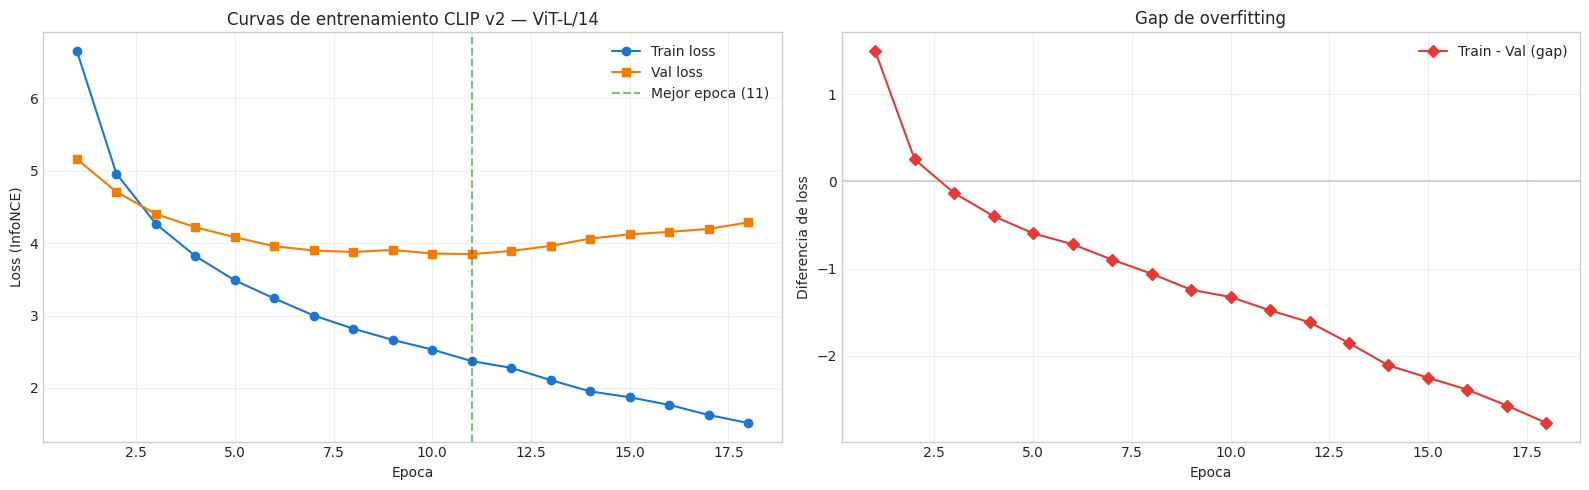

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Loss curves
ax = axes[0]
epochs = range(1, len(train_losses) + 1)
ax.plot(epochs, train_losses, "o-", label="Train loss", color="#1976D2")
ax.plot(range(1, len(val_losses) + 1), val_losses, "s-", label="Val loss", color="#F57C00")

# Marcar mejor epoca
best_epoch = val_losses.index(min(val_losses)) + 1
ax.axvline(best_epoch, color="green", linestyle="--", alpha=0.5, label=f"Mejor epoca ({best_epoch})")

ax.set_xlabel("Epoca")
ax.set_ylabel("Loss (InfoNCE)")
ax.set_title("Curvas de entrenamiento CLIP v2 — ViT-L/14")
ax.legend()
ax.grid(True, alpha=0.3)

# Overfitting gap
ax = axes[1]
gap = [t - v for t, v in zip(train_losses, val_losses)]
ax.plot(epochs, gap, "D-", color="#E53935", label="Train - Val (gap)")
ax.axhline(0, color="gray", linestyle="-", alpha=0.3)
ax.set_xlabel("Epoca")
ax.set_ylabel("Diferencia de loss")
ax.set_title("Gap de overfitting")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Gap de Overfitting y Curva de entrenamiento

El análisis de las curvas de entrenamiento muestra que la pérdida de entrenamiento disminuye de forma continua durante todas las epocas, indicando que
el modelo aprende correctamente las representaciones en el conjunto de entrenamiento. Sin embargo, la pérdida de validación alcanza su mínimo alrededor
de la época 11 para incrementarse ligeramente en las epicas siguientes, y separarse cada vez mas del conjunto de entrenamiento.
Esta divergencia se podria considerar casi lineal.

---
## 6. Evaluacion — Retrieval y per-crop accuracy

In [12]:
# Cargar mejor checkpoint
model.load_state_dict(torch.load("clip_pastis_v2_best.pt", map_location=device, weights_only=True))
model.eval()

# Recolectar embeddings de todo el set de validacion
all_img_feats = []
all_txt_feats = []

with torch.no_grad():
    for images, texts in tqdm(val_loader, desc="Encoding val set"):
        images = images.to(device)
        texts = texts.to(device)

        with autocast("cuda", enabled=use_amp):
            img_f = model.encode_image(images)
            txt_f = model.encode_text(texts)

        all_img_feats.append(F.normalize(img_f.float(), dim=-1).cpu())
        all_txt_feats.append(F.normalize(txt_f.float(), dim=-1).cpu())

all_img_feats = torch.cat(all_img_feats)  # (N, D)
all_txt_feats = torch.cat(all_txt_feats)  # (N, D)

# Matriz de similitud completa
sim_matrix = all_img_feats @ all_txt_feats.t()  # (N, N)


# Recall@K
def recall_at_k(sim, k):
    n = sim.shape[0]
    topk = sim.topk(k, dim=1).indices
    correct = torch.arange(n).unsqueeze(1).expand_as(topk)
    hits = (topk == correct).any(dim=1).float()
    return hits.mean().item()


r1 = recall_at_k(sim_matrix, 1)
r5 = recall_at_k(sim_matrix, 5)
r10 = recall_at_k(sim_matrix, 10)

print(f"Image-to-Text Retrieval (N={len(val_ids)})")
print(f"  Recall@1:  {r1:.3f}")
print(f"  Recall@5:  {r5:.3f}")
print(f"  Recall@10: {r10:.3f}")

Encoding val set: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [02:20<00:00, 35.13s/it]

Image-to-Text Retrieval (N=496)
  Recall@1:  0.054
  Recall@5:  0.210
  Recall@10: 0.359


#### Evaluación del Recall

En este caso, se consideró tomar el Recall para medir la efectividad del algoritmo, y se generó una función para analizar el recall entre k elementos normalizados.
Esto sirve ya que se busca saber que tantos elementos aciertan dentro de un conjunto. Se puede notar que tal vez hayan valores un poco bajos aunque esto tambien
se debe a que la cantidad de epochs hechos para este experimento son algo bajos.

In [13]:

CROP_NAMES = {
    1: "meadow", 2: "soft winter wheat", 3: "corn", 4: "winter barley",
    5: "winter rapeseed", 6: "spring barley", 7: "sunflower", 8: "grapevine",
    9: "beet", 10: "winter triticale", 11: "winter durum wheat",
    12: "fruits vegetables and flowers", 13: "potatoes", 14: "leguminous fodder",
    15: "soybeans", 16: "orchard", 17: "mixed cereal", 18: "sorghum",
}

# Codificar los 18 prompts de cultivos
crop_list = list(CROP_NAMES.values())
crop_prompts = [f"A satellite image containing: {name}" for name in crop_list]
crop_tokens = tokenizer(crop_prompts).to(device)

with torch.no_grad():
    with autocast("cuda", enabled=use_amp):
        crop_text_feats = F.normalize(model.encode_text(crop_tokens).float(), dim=-1)  # (18, D)

# Para cada imagen de validacion, obtener scores vs 18 cultivos
crop_scores = all_img_feats @ crop_text_feats.cpu().t()  # (N_val, 18)

# Ground truth: para cada imagen, cuales cultivos estan presentes
val_gt_crops = []
for pid in val_ids:
    caption = (DATA_DIR / f"{pid}.txt").read_text(encoding="utf-8").strip()
    prefix = "A satellite image containing: "
    crop_str = caption[len(prefix):] if caption.startswith(prefix) else caption
    crops_present = set(c.strip() for c in crop_str.split(","))
    val_gt_crops.append(crops_present)

# Calcular per-crop accuracy con threshold
# Usar el score mediano como threshold adaptativo
threshold = crop_scores.median().item()
print(f"Threshold adaptativo (mediana): {threshold:.4f}\n")

per_crop_results = []
for c_idx, crop_name in enumerate(crop_list):
    # Ground truth: imagenes donde este cultivo aparece
    gt_positive = [crop_name in gt for gt in val_gt_crops]
    n_positive = sum(gt_positive)
    n_negative = len(val_ids) - n_positive

    if n_positive == 0 or n_negative == 0:
        continue

    scores = crop_scores[:, c_idx]
    predicted_positive = scores > threshold

    # Precision: de los que predijo como positivo, cuantos lo son
    tp = sum(1 for pred, gt in zip(predicted_positive, gt_positive) if pred and gt)
    fp = sum(1 for pred, gt in zip(predicted_positive, gt_positive) if pred and not gt)
    fn = sum(1 for pred, gt in zip(predicted_positive, gt_positive) if not pred and gt)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    # Average score para positivos vs negativos
    pos_scores = [s.item() for s, gt in zip(scores, gt_positive) if gt]
    neg_scores = [s.item() for s, gt in zip(scores, gt_positive) if not gt]
    avg_pos = np.mean(pos_scores)
    avg_neg = np.mean(neg_scores)
    separation = avg_pos - avg_neg

    per_crop_results.append({
        "crop": crop_name,
        "n_present": n_positive,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "avg_score_present": avg_pos,
        "avg_score_absent": avg_neg,
        "separation": separation,
    })

df_crops = pd.DataFrame(per_crop_results).sort_values("f1", ascending=False)
print("Per-crop classification metrics:")
print(df_crops.to_string(index=False, float_format="{:.3f}".format))
print(f"\nMacro F1: {df_crops['f1'].mean():.3f}")
print(f"Mean separation (present vs absent): {df_crops['separation'].mean():.4f}")

Threshold adaptativo (mediana): 0.2547

Per-crop classification metrics:
                         crop  n_present  precision  recall    f1  avg_score_present  avg_score_absent  separation
            soft winter wheat        316      0.756   0.785 0.770              0.289             0.254       0.034
                         corn        303      0.723   0.739 0.731              0.272             0.249       0.023
                    grapevine         99      0.650   0.768 0.704              0.300             0.176       0.125
                       meadow        468      0.988   0.534 0.693              0.265             0.212       0.052
              winter rapeseed        144      0.498   0.840 0.625              0.289             0.245       0.044
            leguminous fodder        212      0.465   0.651 0.542              0.282             0.262       0.020
                winter barley        230      0.444   0.604 0.512              0.266             0.268      -0.002
       

#### Análisis especifico por cultivo

Los resulktados muestran que el modelo funciona de manera moderadamente correcta, basandose en el Macro F1 y Mean separation. Algunas clases que son mas representadas
y con caracteristicas visuales mas significativas, como lo es "soft winter wheat", "corn" y "grapevine" presentan valores F1 mayores a 0.7, lo que inidica que se
distinguen mejor en el espacio de _embeddings_.
Sin embargo, tambien existen algunos cultivos que muestran peores desempeños, como lo es "winter barley" que tiene una separación negativa. Se considera cambiar
el umbral global a futuro.

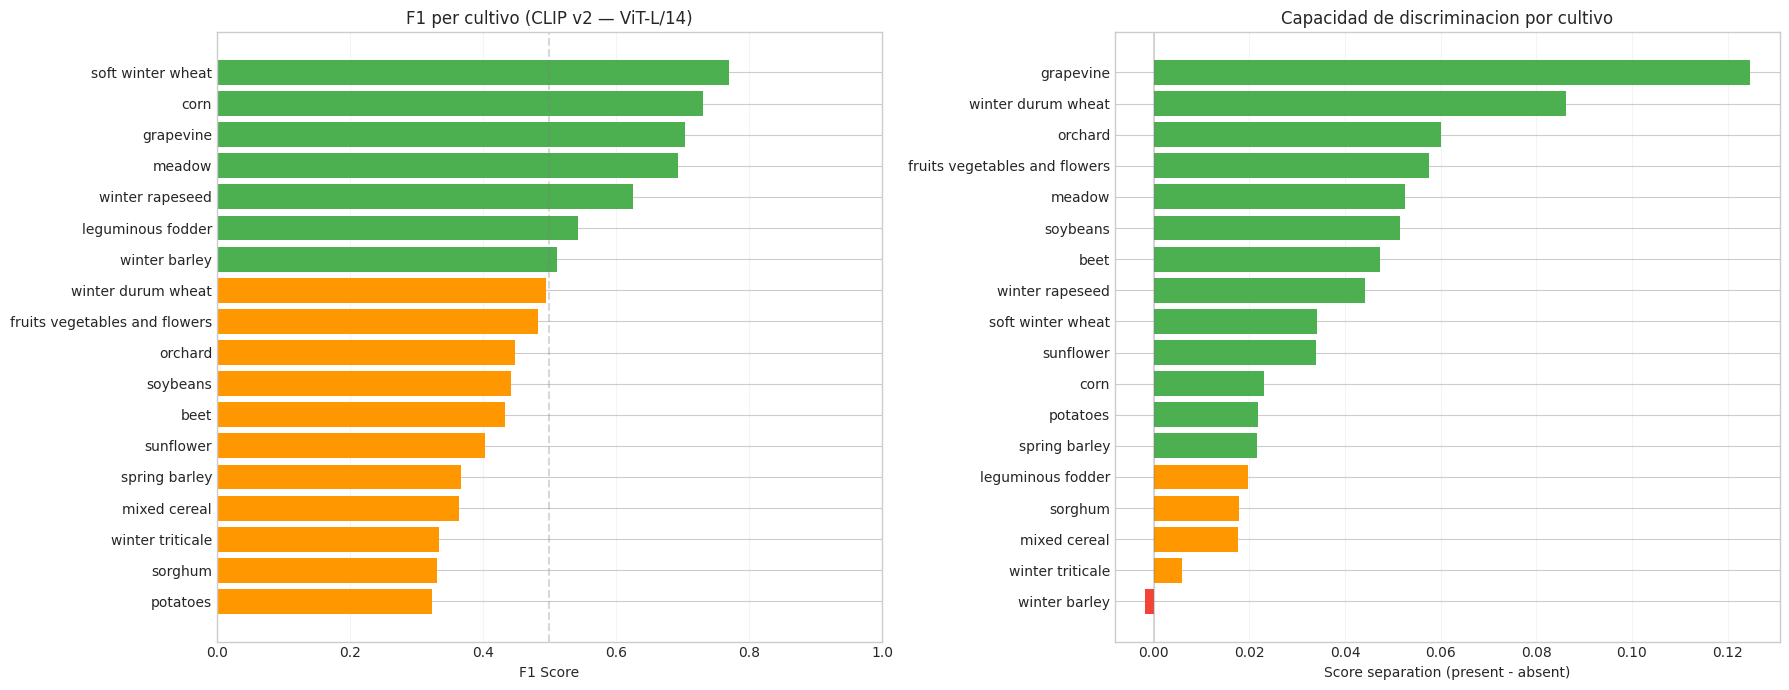

In [14]:

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# F1 por cultivo
ax = axes[0]
df_sorted = df_crops.sort_values("f1", ascending=True)
colors = ["#4CAF50" if f1 > 0.5 else "#FF9800" if f1 > 0.3 else "#F44336" for f1 in df_sorted["f1"]]
ax.barh(df_sorted["crop"], df_sorted["f1"], color=colors, edgecolor="none")
ax.set_xlabel("F1 Score")
ax.set_title("F1 per cultivo (CLIP v2 — ViT-L/14)")
ax.set_xlim(0, 1)
ax.axvline(0.5, color="gray", linestyle="--", alpha=0.3)
ax.grid(True, alpha=0.2, axis="x")

# Separacion de scores (presente vs ausente)
ax = axes[1]
df_sep = df_crops.sort_values("separation", ascending=True)
colors2 = ["#4CAF50" if s > 0.02 else "#FF9800" if s > 0 else "#F44336" for s in df_sep["separation"]]
ax.barh(df_sep["crop"], df_sep["separation"], color=colors2, edgecolor="none")
ax.set_xlabel("Score separation (present - absent)")
ax.set_title("Capacidad de discriminacion por cultivo")
ax.axvline(0, color="gray", linestyle="-", alpha=0.3)
ax.grid(True, alpha=0.2, axis="x")

plt.tight_layout()
plt.show()

#### Continuación métricas

En este caso se muestra una descripción un poco mas gráfica de los f1 y separaciones de cada cultivo. Aqui es mas evidente que el "winter barley" es discriminado
por su desempeño en ser discriminado.

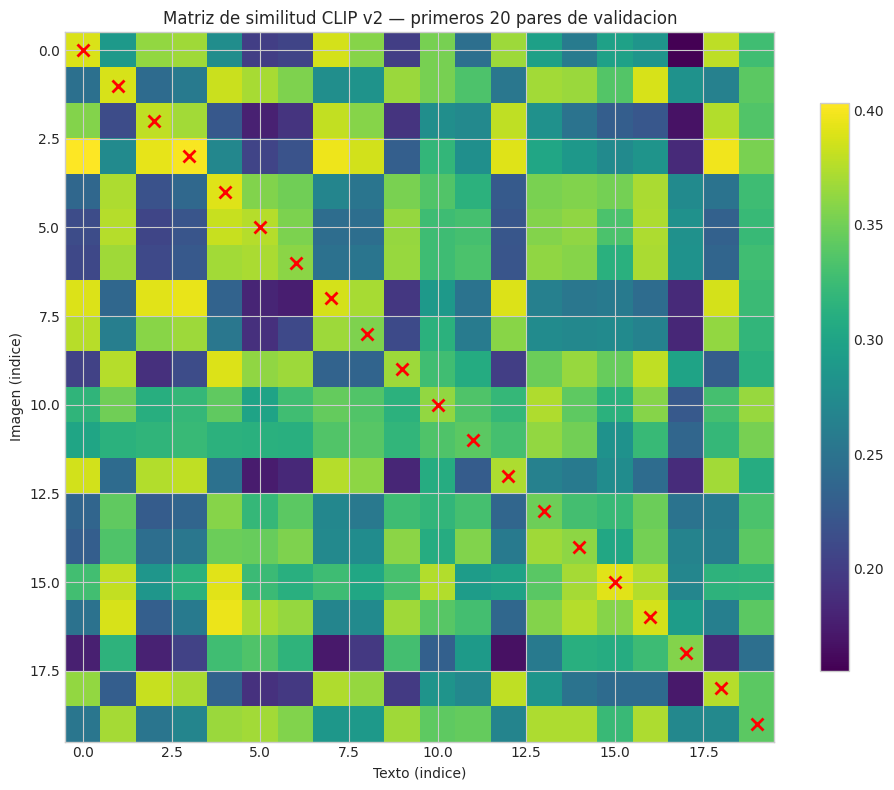

In [15]:

N_SHOW = min(20, len(val_ids))
sim_sub = sim_matrix[:N_SHOW, :N_SHOW].numpy()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(sim_sub, cmap="viridis", vmin=sim_sub.min(), vmax=sim_sub.max())
ax.set_xlabel("Texto (indice)")
ax.set_ylabel("Imagen (indice)")
ax.set_title(f"Matriz de similitud CLIP v2 — primeros {N_SHOW} pares de validacion")
fig.colorbar(im, ax=ax, shrink=0.8)

for i in range(N_SHOW):
    ax.plot(i, i, "rx", markersize=8, markeredgewidth=2)

plt.tight_layout()
plt.show()

#### Generación Matriz de similitud

Esta matriz sirve para comprender un poco mejor de manera gráfica el comportamiento de CLIP y del InfoNCE, ya que es la representación gráfica
de como se comporta el algoritmo CLIP. Esta matriz trata de mostrar la conexion que hay entre los _embeddings_ del texto descriptivo y de la imagen, 
haciendo que las correlaciones traten de ser lo menos parecidas posibles en los casos que se categoricen cosas diferentes

In [1]:

fig, axes = plt.subplots(2, 5, figsize=(22, 8))

val_captions = []
for pid in val_ids:
    caption = (DATA_DIR / f"{pid}.txt").read_text(encoding="utf-8").strip()
    val_captions.append(caption)

for i in range(10):
    row, col = i // 5, i % 5
    ax = axes[row][col]

    # Imagen
    img = Image.open(DATA_DIR / f"{val_ids[i]}.png")
    ax.imshow(img)
    ax.axis("off")

    # Top-3 textos mas similares
    sims = sim_matrix[i]
    top3 = sims.topk(3).indices.tolist()

    real_crops = val_captions[i].replace("A satellite image containing: ", "")

    title = f"Patch {val_ids[i]}\n"
    title += f"Real: {real_crops[:45]}...\n" if len(real_crops) > 45 else f"Real: {real_crops}\n"
    match_str = "MATCH" if top3[0] == i else f"pred #{top3[0]}"
    title += f"Top1: {match_str}"
    ax.set_title(title, fontsize=6, color="green" if top3[0] == i else "red")

plt.suptitle("Ejemplos: imagen -> caption (real vs prediccion CLIP v2)", fontsize=13)
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

---
## 7. Comparacion v1 vs v2

In [2]:

# Intentar cargar resultados de v1
v1_path = Path("clip_pastis_v1_final.pt")
if v1_path.exists():
    v1_data = torch.load(str(v1_path), map_location="cpu", weights_only=False)
    v1_train = v1_data.get("train_losses", [])
    v1_val = v1_data.get("val_losses", [])
    v1_best = v1_data.get("best_val_loss", None)

    print("Comparacion v1 vs v2:")
    print(f"  v1 (ViT-B/32): best_val_loss = {v1_best:.4f} ({len(v1_train)} epocas)")
    print(f"  v2 (ViT-L/14): best_val_loss = {best_val_loss:.4f} ({len(train_losses)} epocas)")
    print(f"  Mejora: {((v1_best - best_val_loss) / v1_best * 100):.1f}%")

    # Plot comparativo
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(range(1, len(v1_train)+1), v1_train, "o--", alpha=0.5, label="v1 train (ViT-B/32)", color="#90CAF9")
    ax.plot(range(1, len(v1_val)+1), v1_val, "s--", alpha=0.5, label="v1 val (ViT-B/32)", color="#FFCC80")
    ax.plot(range(1, len(train_losses)+1), train_losses, "o-", label="v2 train (ViT-L/14)", color="#1976D2")
    ax.plot(range(1, len(val_losses)+1), val_losses, "s-", label="v2 val (ViT-L/14)", color="#F57C00")
    ax.set_xlabel("Epoca")
    ax.set_ylabel("Loss (InfoNCE)")
    ax.set_title("Comparacion de entrenamiento: CLIP v1 vs v2")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No se encontro clip_pastis_v1_final.pt para comparacion.")
    print(f"v2 (ViT-L/14): best_val_loss = {best_val_loss:.4f} ({len(train_losses)} epocas)")

NameError: name 'Path' is not defined

---
## 8. Guardado del modelo

In [ ]:

torch.save({
    "model_state_dict": model.state_dict(),
    "train_losses": train_losses,
    "val_losses": val_losses,
    "best_val_loss": best_val_loss,
    "retrieval_metrics": {
        "recall_at_1": r1,
        "recall_at_5": r5,
        "recall_at_10": r10,
    },
    "per_crop_f1": df_crops[["crop", "f1", "separation"]].to_dict("records"),
    "config": {
        "model": MODEL_NAME,
        "pretrained": PRETRAINED,
        "lr": LR,
        "batch_size": BATCH_SIZE,
        "grad_accum_steps": GRAD_ACCUM_STEPS,
        "effective_batch_size": BATCH_SIZE * GRAD_ACCUM_STEPS,
        "epochs_trained": len(train_losses),
        "train_size": len(train_ids),
        "val_size": len(val_ids),
        "weight_decay": WEIGHT_DECAY,
        "warmup_epochs": 2,
        "patience": PATIENCE,
        "augmentations": [
            "RandomRotation(0/90/180/270)",
            "RandomHorizontalFlip(0.5)",
            "RandomVerticalFlip(0.5)",
            "ColorJitter(b=0.1, c=0.1, s=0.05)",
            "CaptionAugmentation(3 templates)",
        ],
        "mixed_precision": use_amp,
    },
}, "clip_pastis_v2_final.pt")

print("Modelo v2 guardado:")
print(f"  clip_pastis_v2_best.pt   (mejor val_loss={best_val_loss:.4f})")
print(f"  clip_pastis_v2_final.pt  (estado final + config + metricas)")
print(f"\nResumen:")
print(f"  Modelo:           {MODEL_NAME}")
print(f"  Epocas:           {len(train_losses)}")
print(f"  Mejor val loss:   {best_val_loss:.4f}")
print(f"  Recall@1:         {r1:.3f}")
print(f"  Recall@5:         {r5:.3f}")
print(f"  Recall@10:        {r10:.3f}")
print(f"  Macro F1 (crops): {df_crops['f1'].mean():.3f}")